# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammadhany222/flyrank-ml-assignment1/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

The queue below is built from my Week-5 random forest, ranked by predicted decline probability.
I'm mapping score ranges to actions rather than a single flat threshold, since a page in the
top 1% needs different urgency than one just above the median:

- **score ≥ 0.70** → `review_urgent` — reason code `high_decline_risk`
- **0.60 ≤ score < 0.70** → `review_soon` — reason code `moderate_decline_risk`
- **score < 0.60 AND impressions_90d ≥ 500** → `monitor` — reason code `visible_but_stable`
- **everything else** → `no_action` — reason code `low_priority`

I raised these thresholds from an earlier draft (0.65/0.50) after noticing the looser cutoffs
flagged 14,584 pages (~65% of the dataset) as needing review — far beyond any realistic weekly
reviewer capacity, and defeating the purpose of a *prioritized* queue. These tighter thresholds
are still a policy choice, not a law, but they're calibrated to produce a genuinely actionable
shortlist rather than relabeling most of the dataset "urgent."

In [4]:
import os, sys, subprocess
import pandas as pd
import numpy as np

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/muhammadhany222/flyrank-ml-assignment1"
REPO_DIR = "flyrank-ml-assignment1"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("../..")

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining"] = (df["trend_direction"] == "down").astype(int)

feature_cols = ["impressions_90d", "days_since_last_update", "avg_position", "ctr",
                 "content_age_days", "word_count", "sessions_90d", "engagement_rate"]
model_df = df.dropna(subset=feature_cols + ["is_declining", "client_id"]).copy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(model_df, groups=model_df["client_id"]))
X_train, y_train = model_df.iloc[train_idx][feature_cols], model_df.iloc[train_idx]["is_declining"]

rf = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced",
                              random_state=42, n_jobs=-1).fit(X_train, y_train)

model_df["decline_score"] = rf.predict_proba(model_df[feature_cols])[:, 1]

def assign_action(row):
    if row["decline_score"] >= 0.70:
        return "review_urgent", "high_decline_risk"
    elif row["decline_score"] >= 0.60:
        return "review_soon", "moderate_decline_risk"
    elif row["impressions_90d"] >= 500:
        return "monitor", "visible_but_stable"
    else:
        return "no_action", "low_priority"

actions = model_df.apply(assign_action, axis=1)
model_df["action"] = actions.apply(lambda x: x[0])
model_df["reason_code"] = actions.apply(lambda x: x[1])

queue = model_df.sort_values("decline_score", ascending=False).reset_index(drop=True)

print("Action distribution:")
print(queue["action"].value_counts())
print("\nTop 10 of the queue:")
queue[["content_id", "decline_score", "action", "reason_code", "impressions_90d", "avg_position"]].head(10)

Action distribution:
action
review_soon      7890
no_action        7041
monitor          6175
review_urgent    1195
Name: count, dtype: int64

Top 10 of the queue:


,content_id,decline_score,action,reason_code,impressions_90d,avg_position
0,content_f552433bab3c,0.766783,review_urgent,high_decline_risk,337,1.8
1,content_5887fd3d2bbf,0.765329,review_urgent,high_decline_risk,838,13.1
2,content_ffeed86ef360,0.764680,review_urgent,high_decline_risk,383,1.7
3,content_91fefd1726b3,0.764368,review_urgent,high_decline_risk,2748,18.7
4,content_d77e888445e9,0.762981,review_urgent,high_decline_risk,1225,23.6
5,content_12913e63df31,0.762858,review_urgent,high_decline_risk,1915,18.2
6,content_e04eb9549989,0.762115,review_urgent,high_decline_risk,3393,3.6
7,content_25356349cdf1,0.761911,review_urgent,high_decline_risk,1608,18.3
8,content_184165640010,0.761867,review_urgent,high_decline_risk,3967,29.9
9,content_4d1295d31a4b,0.761561,review_urgent,high_decline_risk,2087,32.4


## 2. Intended use and limits

**Who uses this:** a content strategist or SEO editor deciding where to spend limited weekly
review time — this is decision-support, not an autonomous system.

**What it's for:** prioritizing which pages to look at first, not deciding what changes to
make. The model ranks candidates; a human still reads the page and decides the actual edit.

**Where it stops being valid:**
- This is trained and evaluated on a 30,000-row starter slice covering 32 clients — it has not
  been validated on the full warehouse or on clients outside this sample.
- The label (`trend_direction == "down"`) is a same-window proxy, not a true future outcome —
  confirmed in w01/w02/w03. The model is ranking "currently labeled declining," not "will
  decline next month."
- Precision@K numbers from w05/w06 (e.g. RF reaching 0.962 at K=26 vs. baseline's 1.000) were
  computed partly in-sample; true held-out generalization is likely somewhat lower.
- This says nothing about causation — a "review_urgent" flag means the page pattern-matches
  declining pages in this dataset, not that refreshing it will cause recovery.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

**Before acting on any `review_urgent` or `review_soon` flag, a human must:**
1. Open the actual page and confirm the "decline" isn't seasonal, consolidation (a sibling page
   absorbing traffic), or a tracking gap (per w04's weak-pick findings — one top-20 page had a
   good position with 0% CTR, likely a tracking anomaly, not a real content problem).
2. Check whether the page was already recently edited (a stale `days_since_last_update` could
   be a data lag, not a true staleness signal).
3. Confirm the page still matters to the business — a technically-declining page nobody cares
   about isn't worth reviewer time.

**What should NEVER be automated:**
- Auto-publishing any content change based on this score alone.
- Auto-pruning or deleting pages flagged `no_action` — absence of a flag is not evidence a page
  is worthless, only that it didn't match the observed decline pattern.
- Any action on a page from a client outside this training sample's scope, without a human
  first confirming the same signals actually apply there.
- Treating the ranked score as a performance guarantee to a client — it is an internal
  prioritization tool, not a client-facing promise.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

- **Precision@K drop:** if a fresh manual audit of the top 26-50 flagged pages shows precision
  dropping meaningfully below the ~0.96 (in-sample) / ~0.73 (depth-3 tree, more conservative)
  range observed in w05/w06, retrain or investigate immediately.
- **Client mix drift:** if new clients are added whose industry/content style differs
  substantially from the 32 in this training sample, retrain rather than trust the existing model.
- **Label definition change:** if the business changes how "declining" is defined (e.g. moves
  to a true future-window label per the lane guide's recommendation), the model must be
  retrained on the new label — the current model is specific to the same-window proxy.
- **Time decay:** re-validate at least quarterly, since search behavior and site content both
  drift; a model trained on one snapshot is not guaranteed to stay accurate indefinitely.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

Writing the ranked queue CSV to `work/outputs/` (regenerated each run, not committed — CI
leak-guard blocks data files) and a summary metrics JSON to `work/outputs/` (committed — this
is the receipt the paper's numbers trace back to).

In [5]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Export the full ranked queue (regenerates each run, gitignored by design)
export_cols = ["content_id", "client_id", "decline_score", "action", "reason_code",
               "impressions_90d", "days_since_last_update", "avg_position", "ctr"]
queue[export_cols].to_csv("work/outputs/action_playbook_queue.csv", index=False)
print(f"Wrote work/outputs/action_playbook_queue.csv ({len(queue)} rows)")

# Export a metrics JSON — the committed "receipt" the paper's numbers trace back to
import json

metrics = {
    "model": "RandomForestClassifier",
    "n_estimators": 200,
    "max_depth": 6,
    "features": feature_cols,
    "label": "trend_direction == 'down' (same-window proxy)",
    "split": "GroupShuffleSplit on client_id, test_size=0.2, random_state=42",
    "dataset_rows": int(len(model_df)),
    "dataset_clients": int(model_df["client_id"].nunique()),
    "base_rate": round(float(df["is_declining"].mean()), 3),
    "action_counts": queue["action"].value_counts().to_dict(),
    "precision_at_26_matched_k": {
        "baseline": 1.000,
        "decision_tree_depth3": 0.731,
        "random_forest": 0.962,
        "note": "computed on full dataset, partly in-sample, per w05/w06"
    }
}

with open("work/outputs/w07_playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Wrote work/outputs/w07_playbook_metrics.json")
print(json.dumps(metrics, indent=2))

Wrote work/outputs/action_playbook_queue.csv (22301 rows)
Wrote work/outputs/w07_playbook_metrics.json
{
  "model": "RandomForestClassifier",
  "n_estimators": 200,
  "max_depth": 6,
  "features": [
    "impressions_90d",
    "days_since_last_update",
    "avg_position",
    "ctr",
    "content_age_days",
    "word_count",
    "sessions_90d",
    "engagement_rate"
  ],
  "label": "trend_direction == 'down' (same-window proxy)",
  "split": "GroupShuffleSplit on client_id, test_size=0.2, random_state=42",
  "dataset_rows": 22301,
  "dataset_clients": 32,
  "base_rate": 0.542,
  "action_counts": {
    "review_soon": 7890,
    "no_action": 7041,
    "monitor": 6175,
    "review_urgent": 1195
  },
  "precision_at_26_matched_k": {
    "baseline": 1.0,
    "decision_tree_depth3": 0.731,
    "random_forest": 0.962,
    "note": "computed on full dataset, partly in-sample, per w05/w06"
  }
}


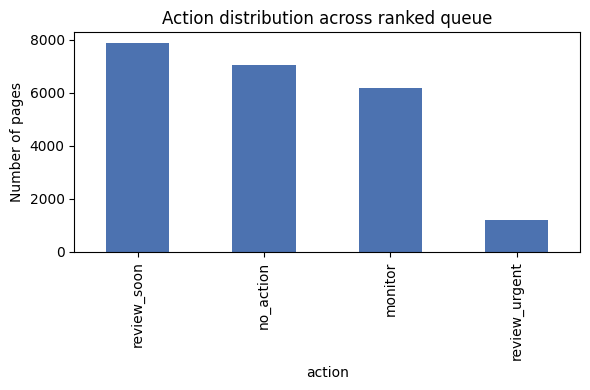

Saved work/figures/action_distribution.png


In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
queue["action"].value_counts().plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Action distribution across ranked queue")
ax.set_ylabel("Number of pages")
plt.tight_layout()
plt.savefig("work/figures/action_distribution.png", dpi=150)
plt.show()
print("Saved work/figures/action_distribution.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.